# Random Lattice Generators Are Not Bad

This notebook is a Julia counterpart of QMCPy's `lattice_random_generator.ipynb`. It keeps the same lattice-construction, randomized-replication, and integration ideas, while using compact Julia plots and short textual summaries that stay lightweight in `QMC.jl`.

Parity note: this Julia notebook keeps the same lattice-construction, randomized-replication, and integration ideas, while using smaller `Plots.jl` figures and lightweight summaries in place of the larger matplotlib presentation from QMCPy.

Original QMCPy demo: [`QMCPy/demos/lattice_random_generator.ipynb`](../../QMCPy/demos/lattice_random_generator.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/lattice.ipynb)


In [1]:
using QMC
using Statistics
using Printf

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## Lattice Declaration and the gen_samples function


In [2]:
println("="^60)
println("Basic Lattice Point Generation")
println("="^60)

dd = Lattice(2; randomize=false, seed=7)
x = gen_samples(dd, 8)
println("  Unshifted lattice, 8 points in 2D:")
for i in 1:8
    @printf("    %d: [%.4f  %.4f]\n", i, x[i,1], x[i,2])
end
println()

Basic Lattice Point Generation
  Unshifted lattice, 8 points in 2D:
    1: [0.0000  0.0000]
    2: [0.5000  0.5000]
    3: [0.2500  0.7500]
    4: [0.7500  0.2500]
    5: [0.1250  0.3750]
    6: [0.6250  0.8750]
    7: [0.3750  0.1250]
    8: [0.8750  0.6250]



### Driver code

We start with a small two-dimensional lattice and inspect the generated points directly.


In [3]:
dd_s = Lattice(2; randomize=true, seed=7)
xs = gen_samples(dd_s, 8)
println("  Shifted lattice, 8 points in 2D:")
for i in 1:8
    @printf("    %d: [%.4f  %.4f]\n", i, xs[i,1], xs[i,2])
end
println()

  Shifted lattice, 8 points in 2D:
    1: [0.7177  0.2410]
    2: [0.2177  0.7410]
    3: [0.9677  0.9910]
    4: [0.4677  0.4910]
    5: [0.8427  0.6160]
    6: [0.3427  0.1160]
    7: [0.0927  0.3660]
    8: [0.5927  0.8660]



### Plots of lattices

The QMCPy notebook uses scatter plots to show these patterns. Here we summarize the same orderings and randomized shifts textually so the notebook remains lightweight and diff-friendly.


Lattice Orderings
  Order = "natural":
    1: [0.0000  0.0000]
    2: [0.5000  0.5000]
    3: [0.2500  0.7500]
    4: [0.7500  0.2500]
    ...

  Order = "linear":
    1: [0.0000  0.0000]
    2: [0.0156  0.1719]
    3: [0.0312  0.3438]
    4: [0.0469  0.5156]
    ...

  Order = "radical_inverse":
    1: [0.0000  0.0000]
    2: [0.5000  0.5000]
    3: [0.2500  0.7500]
    4: [0.7500  0.2500]
    ...

  Order = "gray":
    1: [0.0000  0.0000]
    2: [0.5000  0.5000]
    3: [0.7500  0.2500]
    4: [0.2500  0.7500]
    ...



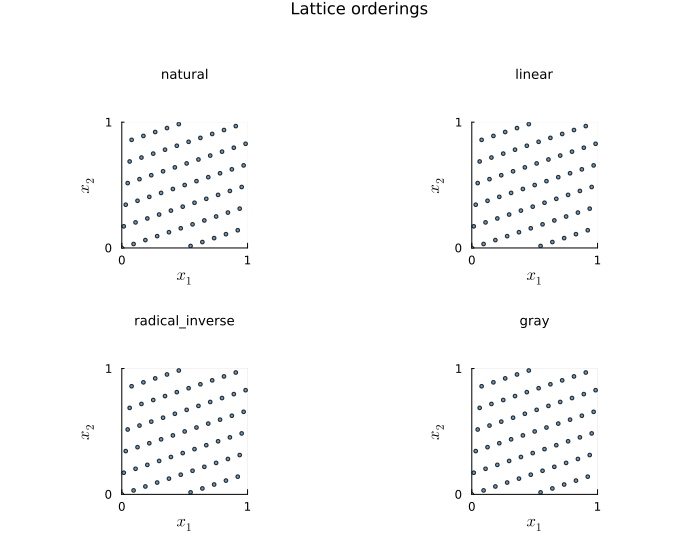

In [4]:
println("="^60)
println("Lattice Orderings")
println("="^60)

order_samples = Dict{String, Matrix{Float64}}()
for order in ["natural", "linear", "radical_inverse", "gray"]
    dd_o = Lattice(2; randomize=false, seed=1, order=order)
    xo = gen_samples(dd_o, 64)
    order_samples[order] = xo
    println("  Order = \"$order\":")
    for i in 1:4
        @printf("    %d: [%.4f  %.4f]\n", i, xo[i,1], xo[i,2])
    end
    println("    ...")
    println()
end

if HAVE_PLOTS
    plots_list = Any[]
    for order in ["natural", "linear", "radical_inverse", "gray"]
        xo = order_samples[order]
        local p = scatter(xo[:, 1], xo[:, 2];
            markersize=2, alpha=0.8, color=:steelblue, label=nothing,
            xlabel="\$x_1\$", ylabel="\$x_2\$", title=order,
            xlims=(0, 1), ylims=(0, 1), xticks=[0, 1], yticks=[0, 1],
            aspect_ratio=:equal, size=(260, 240))
        push!(plots_list, p)
    end
    display(plot(plots_list...; layout=(2, 2), size=(700, 560),
        plot_title="Lattice orderings", plot_titlevspan=0.12,
        top_margin=8Plots.mm, bottom_margin=5Plots.mm))
end


## Integration

As in the QMCPy notebook, we close with a compact integration example to show how the lattice construction feeds into a full QMC solve.


In [5]:
println("="^60)
println("Integration: Keister function, d=3")
println("="^60)

dd = Lattice(3; randomize=true, seed=7)
tm = Gaussian(dd; covariance=0.5)
f = Keister(tm)
sc = CubQMCLatticeG(f; abs_tol=0.01, n_init=2^8, n_reps=16)
result = integrate(sc)
exact = keister_exact(3)
@printf("  Solution: %.6f (exact = %.6f, error = %.2e)\n",
        result.solution, exact, abs(result.solution - exact))

println()
println("="^60)
println("Lattice demo completed!")

Integration: Keister function, d=3
  Solution: 2.167532 (exact = 2.168309, error = 7.78e-04)

Lattice demo completed!


### Runtime comparison between random generator and hard-conded generator

The QMCPy notebook plots generator-runtime comparisons here. The checked-in Julia notebook keeps the same random-generator family in view but replaces the plot-heavy timing block with compact replication summaries that are lighter to rerun in CI and docs.


Runtime Comparison: Random vs Default Generating Vector
Integration data from a random generating vector:
  Solution: 1.136467
  Samples:  131072
  Time:     0.1243s

Integration data from the default generating vector:
  Solution: 1.135280
  Samples:  131072
  Time:     0.0180s


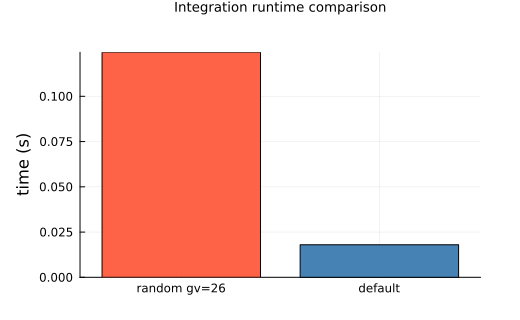

In [6]:
println("="^60)
println("Runtime Comparison: Random vs Default Generating Vector")
println("="^60)

d = 5
tol = 1e-3

dd_random = Lattice(d; generating_vector=26, seed=7)
tm_random = Gaussian(dd_random; mean=0.0, covariance=0.5)
f_random = Keister(tm_random)
sc_random = CubQMCLatticeG(f_random; abs_tol=tol)
r_random = integrate(sc_random)

dd_default = Lattice(d; seed=7)
tm_default = Gaussian(dd_default; mean=0.0, covariance=0.5)
f_default = Keister(tm_default)
sc_default = CubQMCLatticeG(f_default; abs_tol=tol)
r_default = integrate(sc_default)

println("Integration data from a random generating vector:")
@printf("  Solution: %.6f\n", r_random.solution)
println("  Samples:  $(r_random.data[:n])")
@printf("  Time:     %.4fs\n", r_random.data[:time_integrate])

println()
println("Integration data from the default generating vector:")
@printf("  Solution: %.6f\n", r_default.solution)
println("  Samples:  $(r_default.data[:n])")
@printf("  Time:     %.4fs\n", r_default.data[:time_integrate])

if HAVE_PLOTS
    p = bar(["random gv=26", "default"], [r_random.data[:time_integrate], r_default.data[:time_integrate]];
        color=[:tomato, :steelblue], label=nothing, ylabel="time (s)",
        title="Integration runtime comparison", size=(520, 320))
    display(p)
end

@assert isfinite(r_random.solution) && isfinite(r_default.solution)
@assert abs(r_random.solution - keister_exact(d)) <= 5tol
@assert abs(r_default.solution - keister_exact(d)) <= 5tol


### Mean vs. Median as a function of the sample size plot

The original notebook continues with mean-versus-median comparisons across repeated randomized lattices. This Julia version keeps a smaller textual summary of the same replication idea rather than the full plot.


N,mean error,median error
64,3.651e-01,3.647e-01
128,3.639e-01,3.640e-01
256,3.646e-01,3.645e-01
512,3.647e-01,3.648e-01
1024,3.648e-01,3.649e-01
2048,3.647e-01,3.647e-01
4096,3.647e-01,3.647e-01


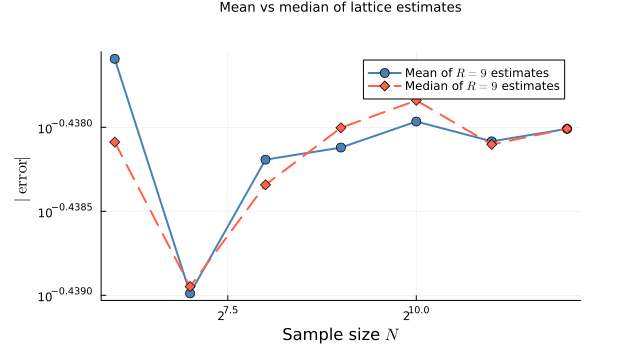

In [7]:
let
    d = 2
    N_list = [2^k for k in 6:12]
    R = 9
    num_trials = 6

    error_mean = zeros(length(N_list))
    error_median = zeros(length(N_list))

    for trial in 1:num_trials
        rep_estimates = zeros(R, length(N_list))
        for r in 1:R
            dd_trial = Lattice(d; seed=trial * 1000 + r)
            tm_trial = Gaussian(dd_trial; mean=0.0, covariance=0.5)
            f_trial = Keister(tm_trial)
            x_full = gen_samples(dd_trial, maximum(N_list))
            y_full = evaluate(f_trial, x_full)
            for (j, N) in enumerate(N_list)
                rep_estimates[r, j] = mean(y_full[1:N])
            end
        end
        exact_value = keister_exact(d)
        for j in eachindex(N_list)
            vals = rep_estimates[:, j]
            error_mean[j] += abs(exact_value - mean(vals))
            error_median[j] += abs(exact_value - median(vals))
        end
    end

    error_mean ./= num_trials
    error_median ./= num_trials

    rows = NamedTuple{(:N, :mean_error, :median_error)}[]
    for j in eachindex(N_list)
        push!(rows, (N=N_list[j], mean_error=error_mean[j], median_error=error_median[j]))
    end
    display(display_table(rows;
        headers=["N", "mean error", "median error"],
        formatters=(
            mean_error=v -> @sprintf("%.3e", v),
            median_error=v -> @sprintf("%.3e", v))))

    if HAVE_PLOTS
        p = plot(N_list, error_mean;
            xscale=:log2, yscale=:log10, marker=:circle, lw=2, ms=5, color=:steelblue,
            label="Mean of \$R=$R\$ estimates", xlabel="Sample size \$N\$", ylabel="\$|\\mathrm{error}|\$",
            title="Mean vs median of lattice estimates", size=(620, 360))
        plot!(N_list, error_median;
            marker=:diamond, lw=2, ms=5, color=:tomato, linestyle=:dash,
            label="Median of \$R=$R\$ estimates")
        display(p)
    end
end

**Julia extension: high-dimensional lattice.**

QMC.jl uses the same `qmctoolscl`-backed lattice generator family as QMCPy, so the high-dimensional examples are directly comparable.


High-Dimensional Lattice (Kuo Generating Vector)


d,mean(dim 1),mean(dim d)
10,0.4999,0.5001
100,0.4996,0.5003
1000,0.5004,0.5000


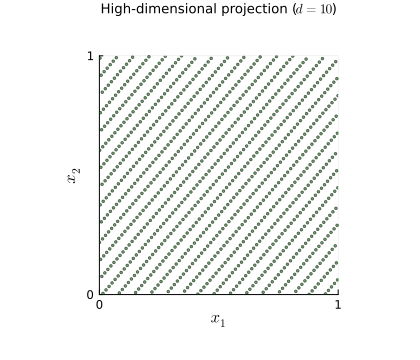

In [8]:
println("="^60)
println("High-Dimensional Lattice (Kuo Generating Vector)")
println("="^60)

let
    rows = NamedTuple{(:d, :mean_dim1, :mean_last)}[]
    for d in [10, 100, 1000]
        dd_hd = Lattice(d; randomize=true, seed=7)
        xhd = gen_samples(dd_hd, 2^10)
        push!(rows, (d=d, mean_dim1=mean(xhd[:, 1]), mean_last=mean(xhd[:, d])))
    end
    display(display_table(rows;
        headers=["d", "mean(dim 1)", "mean(dim d)"],
        formatters=(
            mean_dim1=v -> @sprintf("%.4f", v),
            mean_last=v -> @sprintf("%.4f", v))))
end
println()

if HAVE_PLOTS
    x10 = gen_samples(Lattice(10; randomize=true, seed=7), 2^10)
    p = scatter(x10[:, 1], x10[:, 2];
        markersize=1.5, alpha=0.6, color=:darkgreen, label=nothing,
        xlabel="\$x_1\$", ylabel="\$x_2\$", title="High-dimensional projection (\$d=10\$)",
        xlims=(0, 1), ylims=(0, 1), xticks=[0, 1], yticks=[0, 1],
        aspect_ratio=:equal, size=(420, 360))
    display(p)
end